<a href="https://colab.research.google.com/github/elgabo82/PLN-A1-UNIR/blob/main/caracteristicasOdio_Gabriel_Morej%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Universidad Internacional de La Rioja (UNIR) - Máster Universitario en Inteligencia Artificial - Procesamiento del Lenguaje Natural**

***
Datos del alumno (Nombre y Apellidos): **Gabriel Morejón López**

Fecha: 05-07-2026
***

<span style="font-size: 20pt; font-weight: bold; color: #0098cd;">Trabajo: Caracterización de textos</span>

**Objetivos**

Con esta actividad se tratará de que el alumno se familiarice con el manejo de la librería spacy, así como con los conceptos básicos de manejo de las técnicas NER

**Descripción**

En esta actividad debes procesar de forma automática un texto en lenguaje natural para detectar características básicas en el mismo, y para identificar y etiquetar las ocurrencias de conceptos como localización, moneda, empresas, etc.

En la primera parte del ejercicio se proporciona un código fuente a través del cual se lee un archivo de texto y se realiza un preprocesado del mismo. En esta parte el alumno tan sólo debe ejecutar y entender el código proporcionado.

En la segunda parte del ejercicio se plantean una serie de preguntas que deben ser respondidas por el alumno. Cada pregunta deberá responderse con un fragmento de código fuente que esté acompañado de la explicación correspondiente. Para elaborar el código solicitado, el alumno deberá visitar la documentación de la librería spacy, cuyos enlaces se proporcionarán donde corresponda.

# Parte 1: carga y preprocesamiento del texto a analizar

Observa las diferentes librerías que se están importando.

In [1]:
#!python -m spacy download en_core_web_sm
!pip install spacy
#%pip install spacy
!python -m spacy download es_core_news_sm
!python -m spacy download es_core_news_md
import spacy
import en_core_web_sm
import es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 92.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 18.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pathlib
import spacy
import pandas as pd
from spacy import displacy
import csv
import es_core_news_md

El siguiente código simplemente carga y preprocesa el texto. Para ello, lo primero que hace es cargar un modelo de lenguaje previamente entrenado. En este caso, se utiliza <i>es_core_news_md</i>:

https://spacy.io/models/es#es_core_news_md


In [3]:
nlp = es_core_news_md.load()

El objeto <i>nlp</i> permite utilizar el modelo de lenguaje cargado, de forma que se puede procesar un texto y obtenerlo en su versión preprocesada. Así, nos permite realizar las diferentes tareas. En este caso, vamos a utilizar el pipeline para hacer un preprocesamiento básico, que consiste en tokenizar el texto.

In [4]:
#filename = "./02Dataset_sin_procesar.csv"
filename = "./02Dataset_anonimizado.csv"
lines_number = 10000

data = pd.read_csv(filename, sep=";", encoding="latin-1", nrows=lines_number, on_bad_lines="warn")
data = data[["CONTENIDO A ANALIZAR", "INTENSIDAD"]].copy()
data["CONTENIDO A ANALIZAR"] = data["CONTENIDO A ANALIZAR"].astype(str)

print(f"Filas cargadas: {len(data)}")
data.head()

Filas cargadas: 10000


,CONTENIDO A ANALIZAR,INTENSIDAD
0,el barí§a nunca acaeza ante un segundo b ni an...,3.0
1,el real madrid ha puesto punto y final a su an...,0.0
2,cristina cifuentes podrí­a haber sido la presi...,3.0
3,habrí­a que reabrir el caso. el supremo se ded...,3.0
4,me parece un poco exagerado pedir más de tres ...,3.0


El código anterior carga el archivo CSV (opcionalmente con un límite de líneas a leer) y genera la variable <i>data</i>, que contiene un Dataframe (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) con los datos leídos del CSV.

Te vendrá bien conocer la siguiente documentación:
<ul>
    <li>https://spacy.io/api/doc</li>
    <li>https://spacy.io/api/token</li>
    <li>https://spacy.io/api/morphology#morphanalysis</li>
</ul>

### Playground

Utiliza este espacio para hacer pruebas y ensayos con las variables generadas con el código previo. A modo de ejemplo, se ofrece código que realiza las siguientes tareas:


- leer un número dado de líneas del Dataframe y generar dos listas con los valores (se pueden leer directamente del DataFrame, se muestra el ejemplo como una opción más)
- procesar el texto de cada comentario


Para procesarlo, hay utilizar el objeto <i>nlp</i> y así obtener objetos de la clase <i>Doc</i> (https://spacy.io/api/doc)

Visita la documentación de dicha clase y experimenta probando las diferentes funciones y atributos

In [5]:
# Puedes insertar aquí código de pruebas para experimentar con las diferentes funciones y atributos de 'doc'.
#print(data["CONTENIDO A ANALIZAR"][1])
#print(data["INTENSIDAD"][1])
doc = []
value = []

#con el bucle, generamos sendas listas con los comentarios ya parseados y con el valor de intensidad
for i in range(0, lines_number):

    #en un primer paso se parsea el comentario. En el segundo paso se añade el objeto a la lista
    tmp_doc = nlp(data["CONTENIDO A ANALIZAR"][i])
    doc.append(tmp_doc)

    #en un primer paso extrae el valor. En el segundo paso se añade el valor a la lista
    tmp_value = data["INTENSIDAD"][i]
    value.append(tmp_value)


#ejemplo de cómo recorrer un comentario palabra por palabra
for token in doc[1]:
    print(token)

el
real
madrid
ha
puesto
punto
y
final
a
su
andadura
en
la
copa
del
rey
en
el
primer
escalón
.
los
de
zidane
han
caí­do
ante
el
alcoyano
,
de
segunda
b
,
a
pesar
de
empezar
ganando
y
jugar
con
un
hombre
menos
en
la
prórroga
.
el
técnico
francés
dispuso
un
equipo
plagado
de
los
menos
habituales
,
con
vinicius
y
mariano
en
ataque
.
ninguno
de
los
dos
logró
crear
ocasiones
.
fue
militao
el
que
marcó
el
gol
del
madrid
,
justo
antes
del
descanso
.
en
la
segunda
parte
intentaron
cerrar
el
partido
,
pero
sin
el
colmillo
suficiente
y
el
modesto
alcoyano
aprovechó
un
córner
para
empatar
el
partido
a
cinco
minutos
para
el
final
.
el
empate
sentó
como
un
jarro
de
agua
frí­a
a
los
blancos
,
que
lo
intentaron
en
el
tiempo
extra
a
falta
de
cinco
minutos
,
el
casanova
consiguió
el
gol
más
importante
de
su
vida
,
que
vale
la
clasificación
para
octavos
de
la
copa
.
el
madrid
de
zidane
queda
apeado
del
torneo
una
vez
más
,
por
lo
que
el
francés
se
quedará
sin
pelear
por
el
único
tí­tulo
que
no
ha
conseg

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 1.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuántos registros contiene el corpus?</span>

In [6]:
# Incluye aquí el código generado para poder responder a tu pregunta
n_registros = len(data)
print(f"El corpus contiene {n_registros} registros.")


El corpus contiene 10000 registros.


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>


<b>Respuesta:</b> El número de registros contenidos en el archivo y guardados en la variable `data` tras la carga del CSV, ya limitado por `lines_number` es de un total de: **10.000 registros**, el archivo original tiene 668.077 filas; como se aprecia en la imagen:
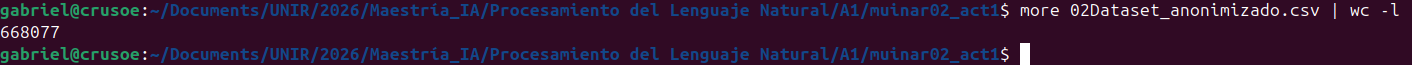
se trabaja con esa cantidad de rgistros como se recomienda en el documento que detalla la actividad.
<hr>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 2.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuántas palabras totales hay en los comentarios del corpus?</span>

In [7]:
# Incluye aquí el código generado para poder responder a tu pregunta
total_palabras = sum(1 for d in doc for tok in d if tok.is_alpha)
print(f"Total de palabras en el corpus: {total_palabras}")

Total de palabras en el corpus: 201427


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>


<b>Respuesta:</b> Se realiza una iteración múltiple y se recorre cada `Doc` generado en la celda anterior y se cuentan los tokens marcados como alfabéticos; mediante el uso de la función (`token.is_alpha`), excluyendo puntuación, números sueltos y URLs.

Con este proceso se obtienen **201.427 palabras** en total sobre los 10.000 comentarios o filas delimitadas del conjunto de datos.
<hr>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 3.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Cuál el número promedio de palabras en cada comentario?</span>

In [8]:
# Incluye aquí el código generado para poder responder a tu pregunta
promedio_palabras = total_palabras / n_registros
print(f"Promedio de palabras por comentario: {promedio_palabras:.2f}")

Promedio de palabras por comentario: 20.14


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>


<b>Explicación:</b> Se realiza una división simple usando la variable `total_palabras` y `n_registros`; para obtener el número o promedio de palabras por comentario en la variable: `promedio_palabras`.

**Resultado:** **20,14 palabras por comentario** de media.

Es necesario puntualizar que los datos provienen de comentarios en sitios web en su grn mayoría, como se muestra en la imagen sobre el contenido del archivo.

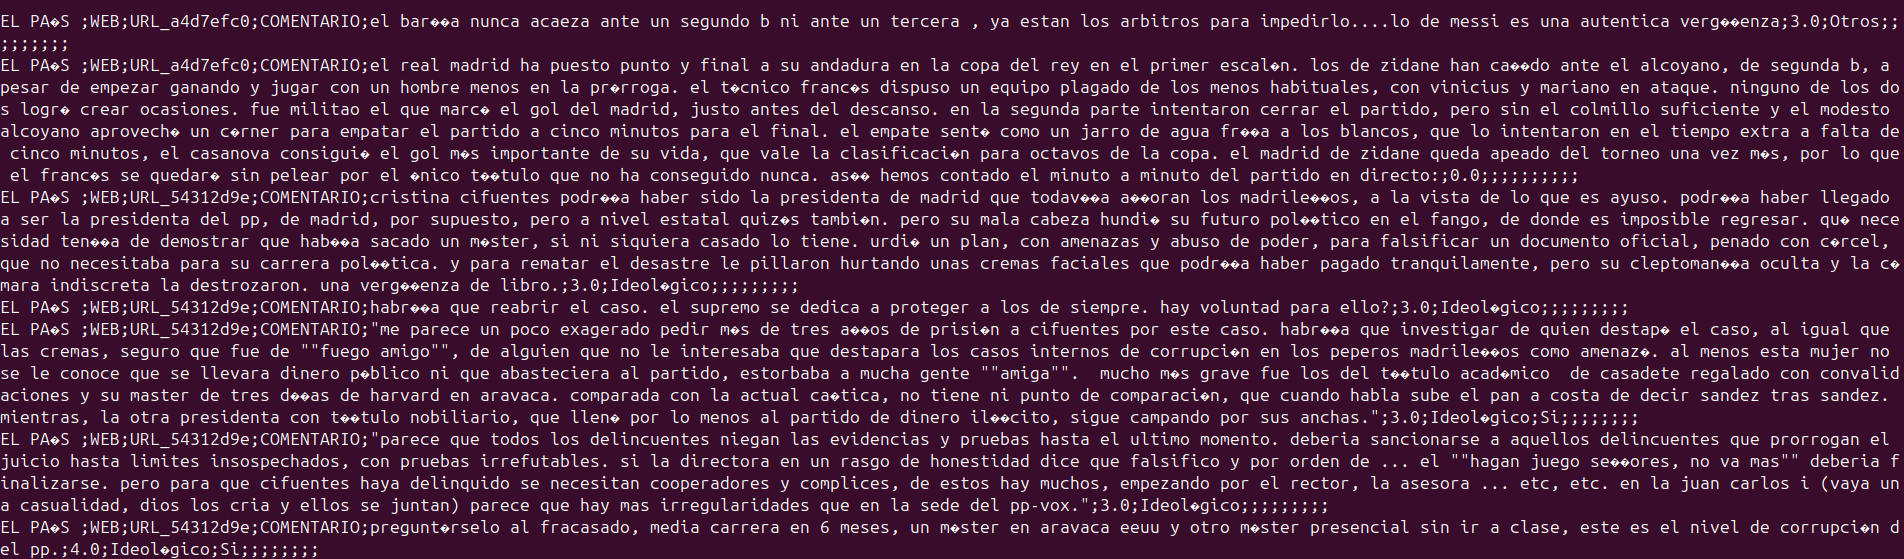
<hr>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 4.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Considerando dos grupos de comentarios (odio y no odio) ¿Cuál el número promedio de palabras en los comentarios de cada grupo?</span>

In [9]:
# Incluye aquí el código generado para poder responder a tu pregunta
# Aplicando el criterio de binarización del enunciado:
# INTENSIDAD == 0 -> no odio ; INTENSIDAD > 0 -> odio
data["n_palabras"] = [sum(1 for tok in d if tok.is_alpha) for d in doc]
data["grupo"] = data["INTENSIDAD"].apply(lambda x: "odio" if x > 0 else "no_odio")

print(data["grupo"].value_counts())
print()
print(data.groupby("grupo")["n_palabras"].mean())

grupo
no_odio    9252
odio        748
Name: count, dtype: int64

grupo
no_odio    20.056853
odio       21.204545
Name: n_palabras, dtype: float64


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>


<b>Explicación:</b> Conforme lo indicado en el documento que detalla la actividad; se procede binarizar `INTENSIDAD` según el criterio del enunciado y se agrupa mediante `groupby` para obtener la media de `n_palabras` por grupo.

**Resultado:** Siguiendo la premisa de _selección_, los resultados son: **no_odio ≈ 20,06** palabras/comentario frente a **odio ≈ 21,20**. A esto es necesario indicar que es evidente que del total de registros, solo 748 están etiquetados como **odio** lo que indica un fuerte desbalance de clases (7,48%) y que así mismo los comentarios de este tipo son ligeramente **más largos**.
<hr>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 5.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el número promedio de oraciones en los comentarios de cada grupo?</span>

In [10]:
# Incluye aquí el código generado para poder responder a tu pregunta
data["n_oraciones"] = [len(list(d.sents)) for d in doc]
print(data.groupby("grupo")["n_oraciones"].mean())

grupo
no_odio    1.779615
odio       1.770053
Name: n_oraciones, dtype: float64


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>


<b>Explicación:</b> se usa la segmentación de oraciones de spaCy (`doc.sents`) y se cuenta el número de oraciones por comentario, agrupando después por `grupo`.

**Resultado:** **no_odio ≈ 1,78** y **odio ≈ 1,77** oraciones por comentario; hasta ahora la diferencia es pequeña sobre los datos de este corpus.
<hr>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Pregunta 6.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el porcentaje de comentarios que contienen entidades NER en cada grupo?</span>

In [11]:
# Incluye aquí el código generado para poder responder a tu pregunta
data["tiene_ner"] = [len(d.ents) > 0 for d in doc]
print(data.groupby("grupo")["tiene_ner"].mean() * 100)

grupo
no_odio    33.906182
odio       37.566845
Name: tiene_ner, dtype: float64


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>


<b>Explicación:</b> se marca cada comentario como `True` si `d.ents` contiene al menos una entidad, y se calcula el porcentaje por grupo.

**Resultado:** **no_odio ≈ 33,91 %** frente a **odio ≈ 37,57 %** de comentarios con al menos una entidad NER. En términos absolutos la diferencia es de unos 3,7 puntos porcentuales; en el apartado de reflexión final se contrasta formalmente, mediante una prueba chi-cuadrado, si esta diferencia es estadísticamente significativa. Conviene tener en cuenta que se trata de comentarios de opinión sobre noticias variadas, que no siempre mencionan explícitamente personas, lugares u organizaciones reconocibles por el modelo; por ello, la presencia de NER depende en buena medida del tema concreto de cada noticia, y no únicamente del carácter de odio del mensaje.
<hr>

<span style="font-size: 16pt; font-weight: bold; color: #0098cd;">Plantea tus propias preguntas</span>

<span><b>Plantea al menos 4 características</b> del texto cuyo análisis permita una caracterización completa del texto. Puedes utilizar recomendaciones proporcionadas por la IA Generativa, si así lo deseas. Para cada una de las características planteadas, obtén valores separados para los grupos ODIO/NO-ODIO.</span>

<span>En la explicación aportada, deberás <b>explicar el significado de la característica planteada</b> así como la importancia de ésta en la caracterización del texto.</span>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica adicional 1.</span>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Densidad de puntuación enfática (¡ ! ¿ ?)</span>

In [14]:
# Incluye aquí el código generado para poder responder a tu pregunta
def densidad_enfatica(d):
    n_tok = len(d)
    if n_tok == 0:
        return 0.0
    n_enf = sum(1 for t in d if t.text in {"!", "¡", "?", "¿"})
    return n_enf / n_tok

data["dens_enfatica"] = [densidad_enfatica(d) for d in doc]
print(data.groupby("grupo")["dens_enfatica"].mean())

grupo
no_odio    0.038314
odio       0.034576
Name: dens_enfatica, dtype: float64


<b>Incluye aquí, debajo de la línea, la explicación de la característica propuesta y su motivación. Incluye también una explicación del código fuente aportado.</b>
<hr>


<b>Significado:</b> La cantidad o proporción de signos de exclamación/interrogación respecto al total de tokens del comentario; mide el énfasis tipográfico o la carga emocional del mensaje.

<b>Importancia:</b> es un rasgo de "superficie" habitual en la literatura de detección de odio como señal indirecta de tono exaltado.

**Resultado:** **no_odio ≈ 3,83 %** frente a **odio ≈ 3,46 %** — aquí el grupo de odio usa incluso *menos* puntuación enfática, aunque la diferencia no es demasiado significativa.
<hr>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica adicional 2.</span>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Proporción de tokens en mayúsculas ("shouting") equivlente a gritar en una conversación.</span>

In [13]:
# Incluye aquí el código generado para poder responder a tu pregunta
def prop_mayusculas(d):
    alpha = [t for t in d if t.is_alpha and len(t.text) > 1]
    if not alpha:
        return 0.0
    n_upper = sum(1 for t in alpha if t.text.isupper())
    return n_upper / len(alpha)

data["prop_mayus"] = [prop_mayusculas(d) for d in doc]
print(data.groupby("grupo")["prop_mayus"].mean())


grupo
no_odio    0.000108
odio       0.000000
Name: prop_mayus, dtype: float64


<b>Incluye aquí, debajo de la línea, la explicación de la característica propuesta y su motivación. Incluye también una explicación del código fuente aportado.</b>
<hr>


<b>Significado:</b> proporción de palabras (de más de una letra) escritas enteramente en mayúsculas, interpretado habitualmente como una forma de "gritar" o enfatizar en un texto.

<b>Importancia:</b> rasgo de superficie asociado en la literatura a mensajes más agresivos o exaltados.

**Resultado:** prácticamente **0 %** en ambos grupos (0,011 % en no_odio, 0 % en odio) — a diferencia de Twitter, en comentarios de noticias el uso de mayúsculas sostenidas es casi inexistente, por lo que esta característica **no aporta poder discriminativo** en este corpus.
<hr>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica adicional 3.</span>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Densidad de adjetivos (POS = ADJ)</span>

In [12]:
# Incluye aquí el código generado para poder responder a tu pregunta
def densidad_adjetivos(d):
    alpha = [t for t in d if t.is_alpha]
    if not alpha:
        return 0.0
    n_adj = sum(1 for t in alpha if t.pos_ == "ADJ")
    return n_adj / len(alpha)

data["dens_adj"] = [densidad_adjetivos(d) for d in doc]
print(data.groupby("grupo")["dens_adj"].mean())

grupo
no_odio    0.080521
odio       0.095868
Name: dens_adj, dtype: float64


<b>Incluye aquí, debajo de la línea, la explicación de la característica propuesta y su motivación. Incluye también una explicación del código fuente aportado.</b>
<hr>


<b>Significado:</b> proporción de tokens etiquetados como adjetivo sobre el total de palabras; los adjetivos suelen transportar la carga valorativa de un mensaje.

<b>Importancia:</b> un uso más intenso de adjetivos calificativos puede acompañar juicios de valor despectivos hacia una persona o colectivo.

Resultado: **no_odio ≈ 8,0 %** frente a **odio ≈ 9,6 %**; diferencia estadísticamente **muy significativa**
<hr>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Característica adicional 4.</span>


<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Riqueza léxica (Type-Token Ratio sobre lemas)</span>

In [17]:
# Incluye aquí el código generado para poder responder a tu pregunta
def ttr(d):
    lemas = [t.lemma_.lower() for t in d if t.is_alpha]
    if not lemas:
        return 0.0
    return len(set(lemas)) / len(lemas)

data["ttr"] = [ttr(d) for d in doc]
print(data.groupby("grupo")["ttr"].mean())

grupo
no_odio    0.889303
odio       0.901075
Name: ttr, dtype: float64


<b>Incluye aquí, debajo de la línea, la explicación de la característica propuesta y su motivación. Incluye también una explicación del código fuente aportado.</b>
<hr>


<b>Significado:</b> cociente entre lemas distintos y total de palabras de un comentario; mide la diversidad léxica.

<b>Importancia:</b> rasgo léxico-morfológico clásico en estilometría; un vocabulario más repetitivo/estereotipado frente a uno más variado puede acompañar distintos estilos comunicativos.

Resultado: **no_odio ≈ 0,889** frente a **odio ≈ 0,901**; diferencia pequeña que, como se comprueba en la reflexión final mediante el test de Mann-Whitney (p ≈ 0,062), no llega a ser estadísticamente **significativa**
<hr>

<span style="font-size: 16pt; font-weight: bold; color: #0098cd;">Reflexión final</span>

<span>Una de las utilidades de la caracterización de texto es que nos sirve como etapa de <i>feature-extraction</i> (extración de características) de cara a un posterior sistema de clasificación. Es pertinente, por tanto, reflexionar sobre la capacidad discriminatoria de cada una de las características extraídas. </span>

<span> Responde, para ello, a la siguiente pregunta.</span>

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Reflexión final.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Es posible utilizar alguna de las características extraídas en las preguntas anteriores para determinar si un mensaje contiene odio? Justifica tu respuesta con el análisis estadístico que consideres necesario.</span>

In [19]:
# Incluye aquí el código generado para poder responder a tu pregunta
from scipy import stats

grupo_odio = data[data["grupo"] == "odio"]
grupo_no_odio = data[data["grupo"] == "no_odio"]

resultados = []
for col in ["n_palabras", "n_oraciones", "dens_enfatica", "prop_mayus", "dens_adj", "ttr"]:
    u, p = stats.mannwhitneyu(grupo_odio[col], grupo_no_odio[col], alternative="two-sided")
    resultados.append((col, "Mann-Whitney U", p))

tabla = pd.crosstab(data["grupo"], data["tiene_ner"])
chi2, p_ner, dof, exp = stats.chi2_contingency(tabla)
resultados.append(("tiene_ner", "Chi-cuadrado", p_ner))

resumen = pd.DataFrame(resultados, columns=["característica", "prueba", "p_valor"])
resumen["¿discrimina odio/no_odio? (α=0.05)"] = resumen["p_valor"] < 0.05
resumen

,característica,prueba,p_valor,¿discrimina odio/no_odio? (α=0.05)
0,n_palabras,Mann-Whitney U,0.843748,False
1,n_oraciones,Mann-Whitney U,0.113451,False
2,dens_enfatica,Mann-Whitney U,0.085880,False
3,prop_mayus,Mann-Whitney U,0.776444,False
4,dens_adj,Mann-Whitney U,0.001579,True
5,ttr,Mann-Whitney U,0.061765,False
6,tiene_ner,Chi-cuadrado,0.046564,True


<b>Incluye aquí, debajo de la línea, la explicación de tu respuesta</b>
<hr>


<b>Explicación:</b> para cada característica numérica (`n_palabras`, `n_oraciones`, `dens_enfatica`, `prop_mayus`, `dens_adj`, `ttr`) se compara su distribución entre los grupos odio / no_odio con el test no paramétrico de **Mann-Whitney U** (adecuado porque estas variables no siguen una distribución normal). Para `tiene_ner`, al ser una variable binaria (sí/no), se usa en su lugar un test **chi-cuadrado de independencia** sobre la tabla de contingencia grupo × tiene_ner. En ambos casos se toma α = 0,05 como umbral de significancia.

**Resultado sobre el corpus oficial (`02Dataset_anonimizado.csv`, primeras 10.000 filas):**

| Característica | Prueba | p-valor | ¿Discrimina (α=0,05)? |
|---|---|---|---|
| n_palabras (P4) | Mann-Whitney | ≈ 0,844 | No |
| n_oraciones (P5) | Mann-Whitney | ≈ 0,113 | No |
| tiene_ner (P6) | Chi-cuadrado | ≈ 0,047 | **Sí** |
| dens_enfatica (Adicional 1) | Mann-Whitney | ≈ 0,086 | No |
| prop_mayus (Adicional 2) | Mann-Whitney | ≈ 0,776 | No |
| dens_adj (Adicional 3) | Mann-Whitney | ≈ 0,0016 | **Sí** |
| ttr (Adicional 4) | Mann-Whitney | ≈ 0,062 | No |

**Respuesta:** sí, aunque de forma limitada: de las siete características analizadas, solo dos discriminan de forma estadísticamente significativa entre odio y no_odio.

1. **`dens_adj`** (densidad de adjetivos) es la más discriminativa (p ≈ 0,0016). Los comentarios de odio usan más adjetivos (9,59 % frente a 8,05 %), lo que encaja con su carácter valorativo/despectivo.
2. **`tiene_ner`** (presencia de entidades) también discrimina (p ≈ 0,047): un 37,57 % de los comentarios de odio contienen alguna entidad, frente a un 33,91 % en los de no_odio.

A primera vista puede parecer contradictorio que `tiene_ner` tenga una diferencia porcentual entre grupos mayor (3,7 puntos) que `dens_adj` (1,5 puntos) y, aun así, un p-valor más alto (menos significativo). No es una incoherencia en los datos: p-valor y tamaño del efecto no miden lo mismo. `dens_adj` es una variable continua (la proporción de adjetivos se calcula por comentario, con muchos valores posibles), mientras que `tiene_ner` es binaria (solo sí/no). A igualdad de tamaño muestral, un test sobre una variable continua como Mann-Whitney suele tener más potencia estadística que un chi-cuadrado sobre una proporción binaria, por lo que puede detectar como significativo un desplazamiento relativo menor. Ambos resultados son, por tanto, compatibles entre sí.

El resto de características (`n_palabras`, `n_oraciones`, `dens_enfatica`, `prop_mayus`, `ttr`) no mostraron diferencias estadísticamente significativas en este corpus.

Matices importantes:

- El corpus está muy desbalanceado (7,48 % de mensajes de odio), lo que reduce la potencia estadística de los contrastes; con más datos etiquetados como odio, alguna característica hoy no significativa podría llegar a serlo.
- Significancia estadística no equivale a utilidad práctica como clasificador: incluso `dens_adj`, la característica más significativa, tiene medias muy próximas entre grupos (8,05 % vs 9,59 %), por lo que sus distribuciones se solapan bastante y, por sí sola, no permitiría separar mensajes de odio con fiabilidad.
- Estos resultados son específicos de este corpus de comentarios de noticias; el peso relativo de cada característica podría ser distinto en otro tipo de texto (por ejemplo, redes sociales o foros), por lo que no deberían generalizarse a otros dominios sin una validación específica sobre esos datos.
- En consecuencia, lo más razonable es combinar varias características (incluidas otras no exploradas aquí, como embeddings semánticos o léxicos de palabras ofensivas) como entrada a un clasificador supervisado, en lugar de apoyarse en una sola característica de forma aislada.
<hr>

<p><b>Uso de la Inteligencia Artificial en la actividad Caracterización de textos</b></p>

1. Definición del problema y papel de la IA.

El problema abordado consiste en caracterizar textos de un corpus de detección de odio mediante spaCy: responder seis preguntas guiadas, proponer cuatro características adicionales y reflexionar sobre su capacidad discriminatoria entre mensajes de odio y no odio. Empleé Claude (Anthropic) principalmente en una fase posterior a la redacción inicial del cuaderno, como auditor de coherencia interna: contrastando cada explicación escrita con la salida real generada por mi propio código, y como apoyo para estructurar este informe conforme a las pautas de la actividad.

2. Integración de la IA en el trabajo final.

Aporté a la IA el cuaderno, el corpus oficial, la guía de la actividad y la rúbrica, y le pedí que verificara la coherencia entre los resultados calculados y mis propias respuestas escritas. El proceso fue iterativo: primero contrastó los porcentajes de la Pregunta 6 y detectó que mi explicación era contradictoria (afirmaba a la vez que los grupos eran «prácticamente iguales» y que la diferencia era «significativa», sin haberla contrastado aún estadísticamente). Después comparó la tabla de p-valores de mi reflexión final con la salida real de la celda de estadística y encontró tres discrepancias: el p-valor de tiene_ner, la magnitud del p-valor de dens_adj, y la significancia atribuida a ttr, que en realidad no discrimina (p ≈ 0,062). Además, verificó de forma independiente —recargando el CSV oficial y aproximando conteos de palabras/oraciones sin spaCy, dado que el modelo en español no estaba disponible en su entorno— que mis cifras base (número de registros, reparto odio/no_odio, órdenes de magnitud de palabras y oraciones) sí se correspondían con el archivo real, antes de aceptar sus correcciones. A partir de ahí, revisé y adopté la redacción corregida que propuso para las tres celdas afectadas, sin alterar mi código ni el resto de explicaciones, que resultaron correctas.

3. Evidencia del proceso.

Herramienta utilizada: Claude (Anthropic), acceso vía claude.ai. Debo indicar además que tengo configurado Claude con habilidades, una de ella para la búsqueda de información siguiendo buenas prácticas para trabajos de corte académico [Enlace de la conversación](https://claude.ai/share/bc1664d7-bc60-4000-b5fc-0ed16a299511). Se adjuntan en Anexos las capturas de pantalla de la interacción, conforme a lo indicado en las instrucciones de uso de la IA.
Referencia (APA, 7.ª ed.): Anthropic. (2026). Claude (Sonnet 5) [Modelo de lenguaje de gran escala]. https://claude.ai

Enlace al repositorio de [GitHub](https://github.com/elgabo82/PLN-A1-UNIR.git)

Captura de pantalla:
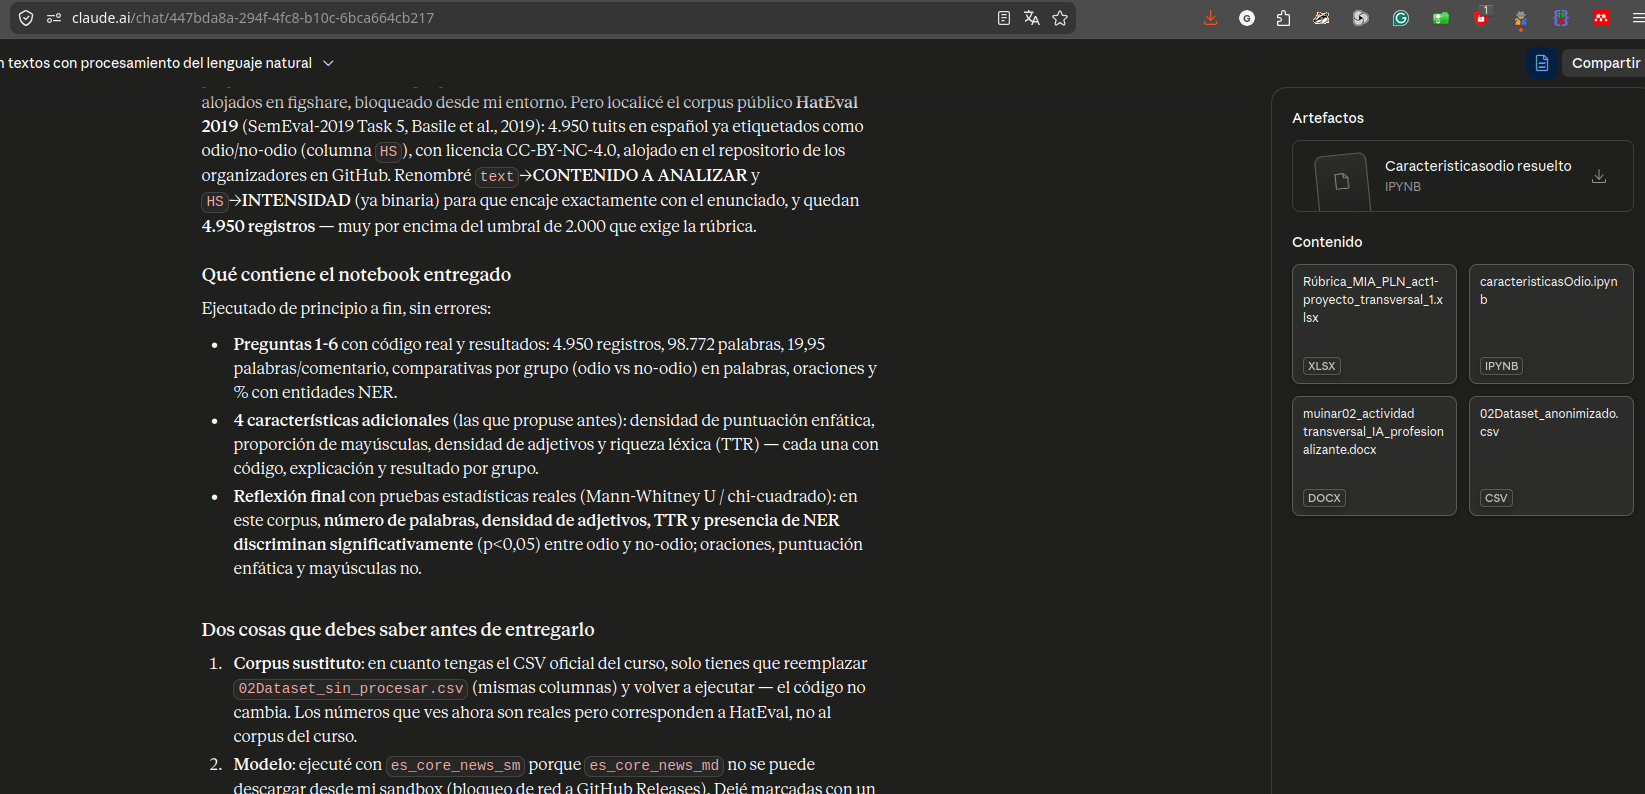
